In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_store_sales.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [5]:
df.shape

(12575, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [7]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [8]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [9]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


In [10]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [11]:
df.isnull().mean() * 100

,0
Transaction ID,0.000000
Customer ID,0.000000
Category,0.000000
Item,9.646123
Price Per Unit,4.842942
Quantity,4.803181
Total Spent,4.803181
Payment Method,0.000000
Location,0.000000
Transaction Date,0.000000


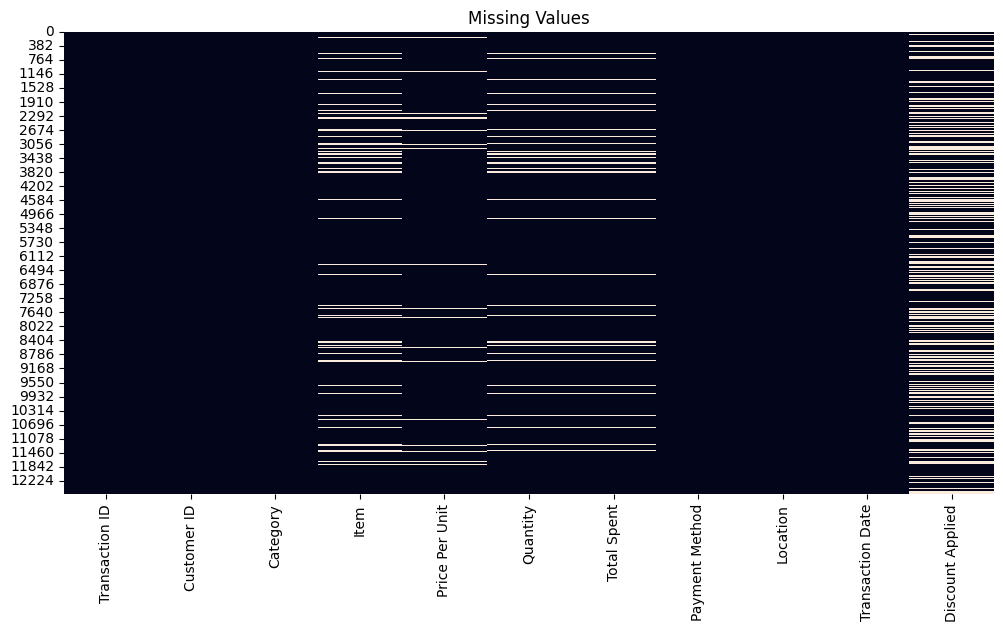

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Category"].value_counts()

,count
Category,
Electric household essentials,1591
Furniture,1591
Food,1588
Milk Products,1584
Butchers,1568
Beverages,1567
Computers and electric accessories,1558
Patisserie,1528


In [15]:
df["Payment Method"].value_counts()

,count
Payment Method,
Cash,4310
Digital Wallet,4144
Credit Card,4121


In [16]:
df["Location"].value_counts()

,count
Location,
Online,6354
In-store,6221


In [17]:
df["Item"].value_counts()

,count
Item,
Item_2_BEV,126
Item_25_FUR,113
Item_11_FUR,110
Item_16_MILK,109
Item_1_MILK,109
...,...
Item_5_BEV,7
Item_13_BEV,7
Item_13_FUR,7


In [18]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Transaction ID : 12575
Customer ID : 25
Category : 8
Item : 200
Price Per Unit : 25
Quantity : 10
Total Spent : 227
Payment Method : 3
Location : 2
Transaction Date : 1114
Discount Applied : 2


In [19]:
df["Transaction Date"].dtype

dtype('O')

In [22]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

#Tarixdən yeni sütunların yaradılması
df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["Day"] = df["Transaction Date"].dt.day
df["Day of Week"] = df["Transaction Date"].dt.day_name()

In [23]:
df["Month Name"] = df["Transaction Date"].dt.month_name()

In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe()

,Price Per Unit,Quantity,Total Spent,Year,Month,Day
count,11966.000000,11971.000000,11971.000000,12575.000000,12575.000000,12575.000000
mean,23.365912,5.536380,129.652577,2023.042386,6.366441,15.633002
std,10.743519,2.857883,94.750697,0.855581,3.503156,8.803184
min,5.000000,1.000000,5.000000,2022.000000,1.000000,1.000000
25%,14.000000,3.000000,51.000000,2022.000000,3.000000,8.000000
50%,23.000000,6.000000,108.500000,2023.000000,6.000000,15.000000
75%,33.500000,8.000000,192.000000,2024.000000,9.000000,23.000000
max,41.000000,10.000000,410.000000,2025.000000,12.000000,31.000000


In [25]:
df[["Price Per Unit","Quantity","Total Spent"]].describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [26]:
df["Calculated Total"] = df["Price Per Unit"] * df["Quantity"]

In [27]:
df[["Price Per Unit","Quantity","Total Spent","Calculated Total"]].head()

,Price Per Unit,Quantity,Total Spent,Calculated Total
0,18.5,10.0,185.0,185.0
1,29.0,9.0,261.0,261.0
2,21.5,2.0,43.0,43.0
3,27.5,9.0,247.5,247.5
4,12.5,7.0,87.5,87.5


In [29]:
df["Difference"] = df["Total Spent"] - df["Calculated Total"]
df["Difference"].value_counts()

,count
Difference,
0.0,11362


In [30]:
category_sales = df.groupby("Category")["Total Spent"].sum().sort_values(
    ascending=False)

category_sales

,Total Spent
Category,
Butchers,208118.0
Electric household essentials,203813.5
Beverages,197047.5
Furniture,195310.0
Food,194812.0
Computers and electric accessories,190692.5
Patisserie,182165.5
Milk Products,180112.0


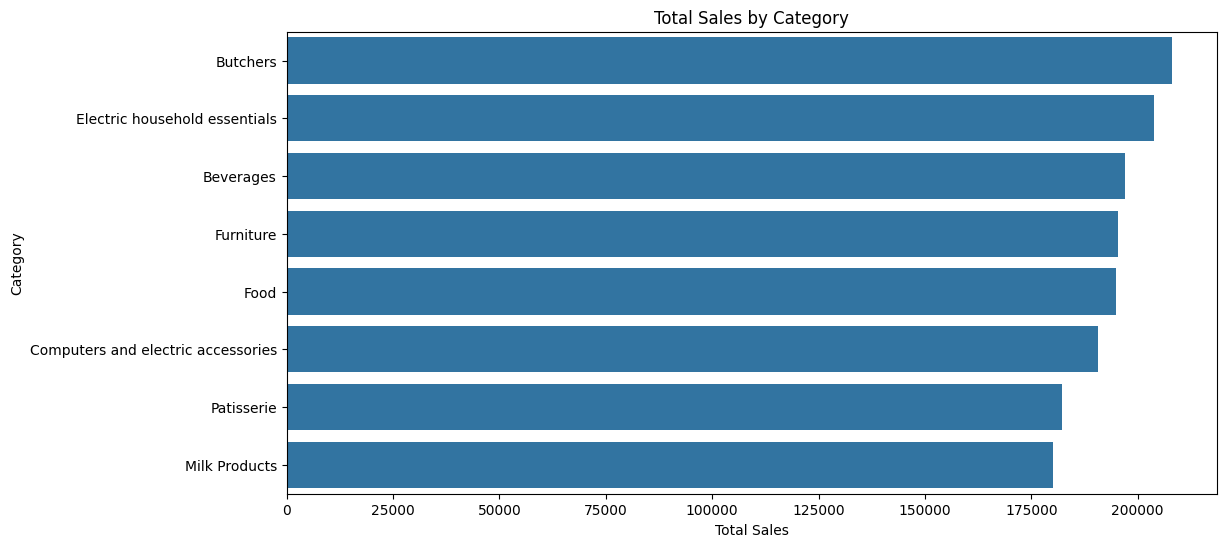

In [31]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index)

plt.title("Total Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.show()

In [32]:
df.groupby("Category")["Total Spent"].mean().sort_values(
    ascending=False)

,Total Spent
Category,
Butchers,139.116310
Electric household essentials,134.441623
Beverages,131.716243
Food,129.271400
Computers and electric accessories,129.107989
Furniture,128.072131
Patisserie,126.416031
Milk Products,119.042961


In [33]:
payment_sales = df.groupby("Payment Method")["Total Spent"].sum()

payment_sales

,Total Spent
Payment Method,
Cash,537710.0
Credit Card,507082.0
Digital Wallet,507279.0


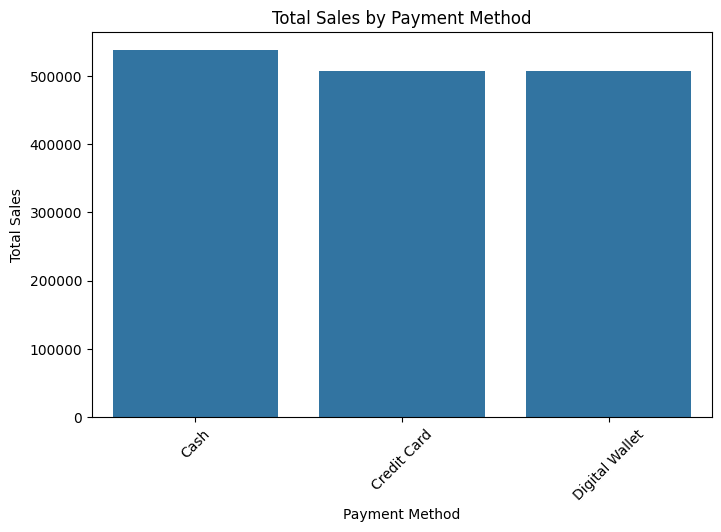

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [35]:
location_sales = df.groupby("Location")["Total Spent"].sum()

location_sales

,Total Spent
Location,
In-store,760670.0
Online,791401.0


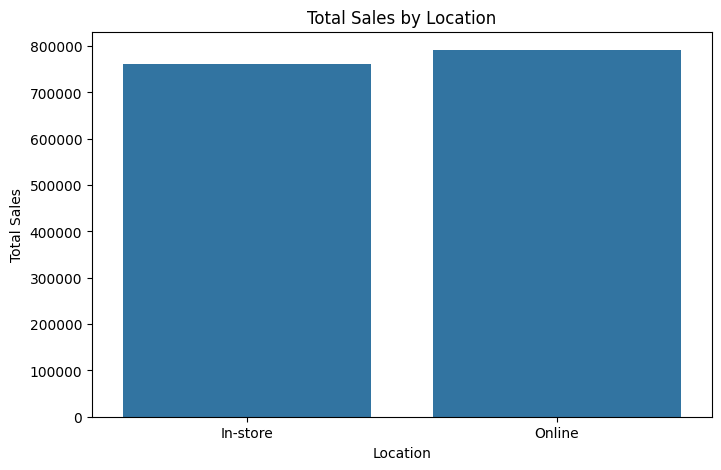

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=location_sales.index,
    y=location_sales.values)

plt.title("Total Sales by Location")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.show()

In [37]:
yearly_sales = df.groupby("Year")["Total Spent"].sum()

yearly_sales

,Total Spent
Year,
2022,510329.5
2023,491312.0
2024,524881.0
2025,25548.5


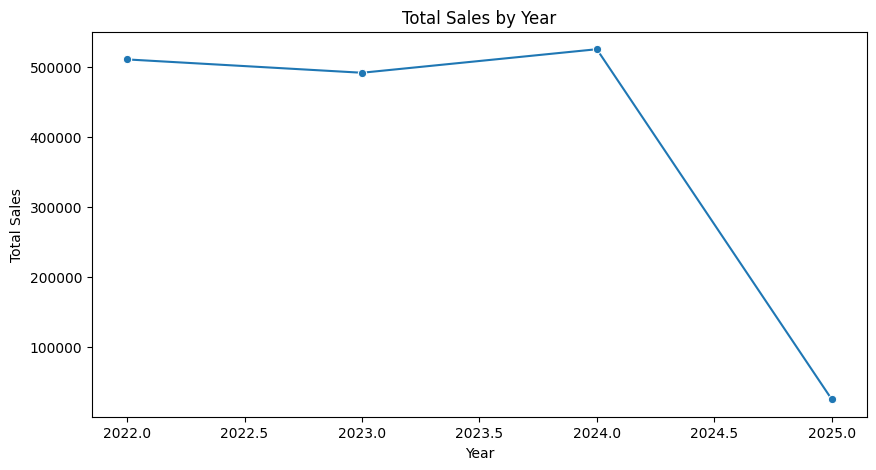

In [38]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker="o")

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

In [39]:
monthly_sales = df.groupby("Month")["Total Spent"].sum()

monthly_sales

,Total Spent
Month,
1,174421.0
2,119685.0
3,122392.0
4,125618.5
5,124594.5
6,129771.0
7,131509.0
8,123287.5
9,129344.0


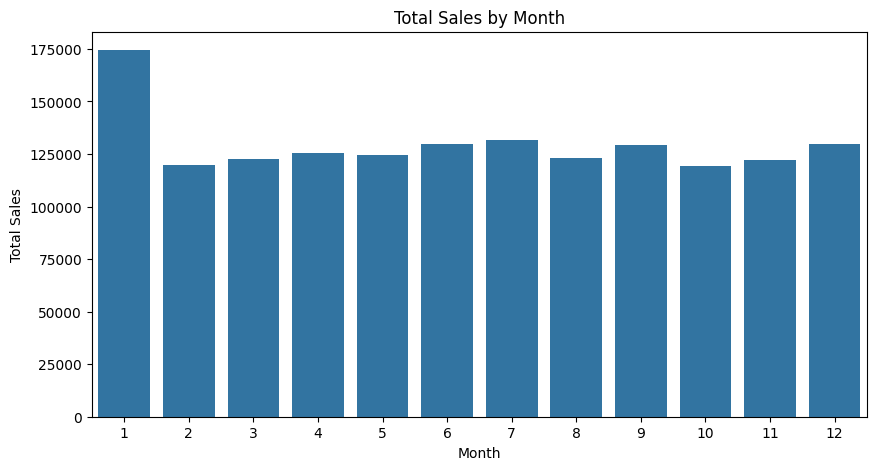

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values)

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

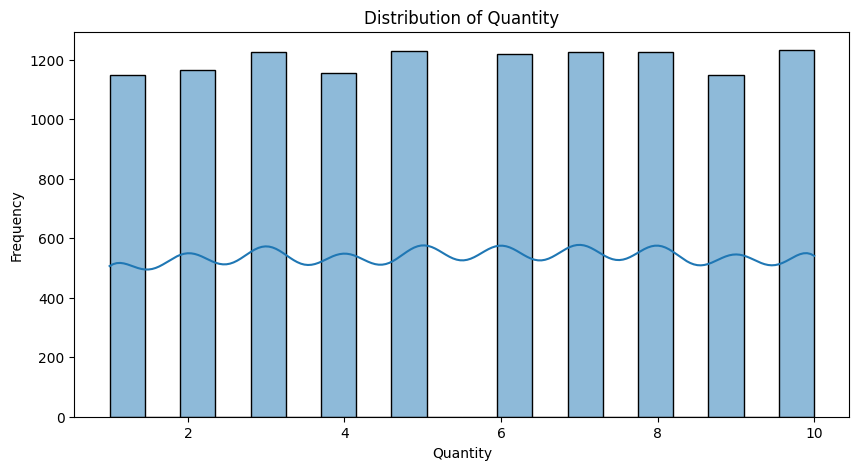

In [41]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Quantity"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

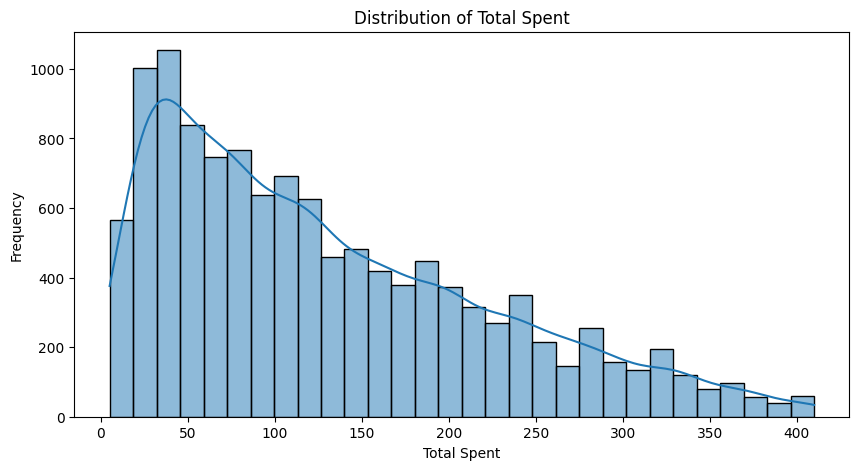

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Total Spent"].dropna(),
    bins=30,
    kde=True)

plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

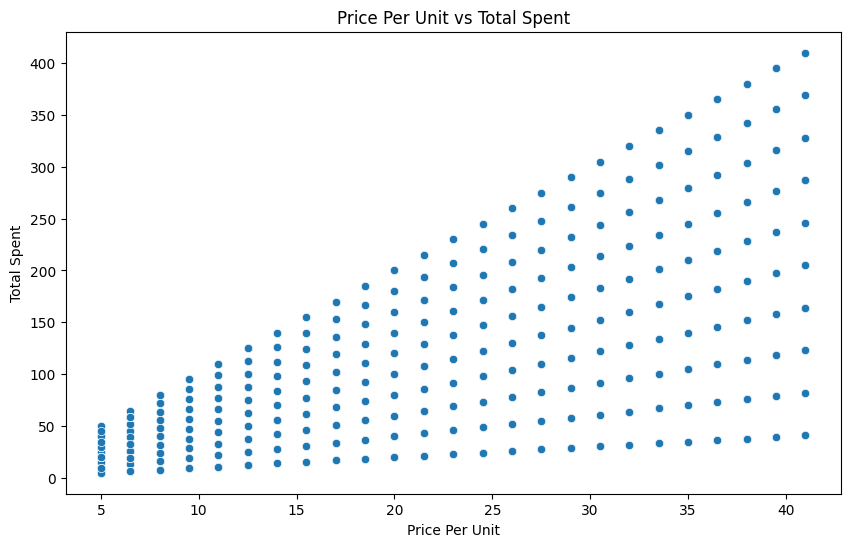

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Price Per Unit",
    y="Total Spent"
)

plt.title("Price Per Unit vs Total Spent")
plt.xlabel("Price Per Unit")
plt.ylabel("Total Spent")
plt.show()

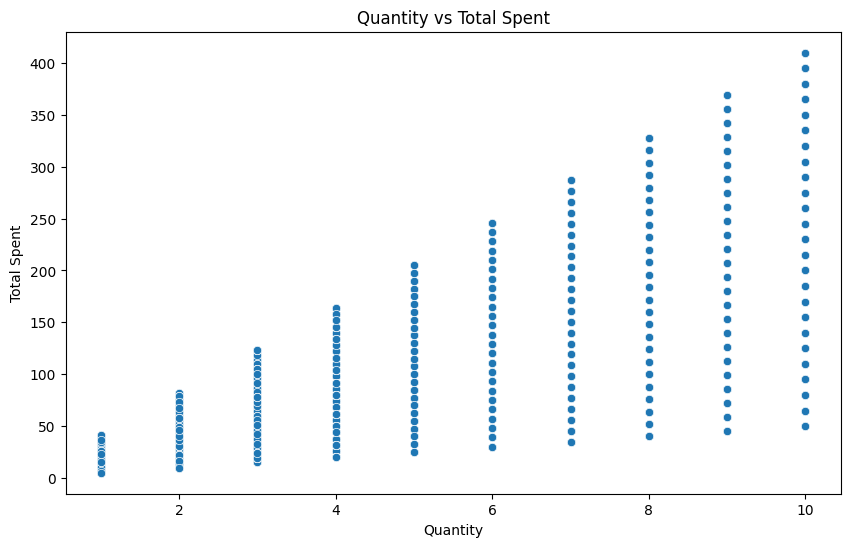

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total Spent"
)

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")
plt.show()

In [45]:
correlation = df[
    ["Price Per Unit", "Quantity", "Total Spent"]
].corr()

correlation

,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000000,0.011801,0.630902
Quantity,0.011801,1.000000,0.712069
Total Spent,0.630902,0.712069,1.000000


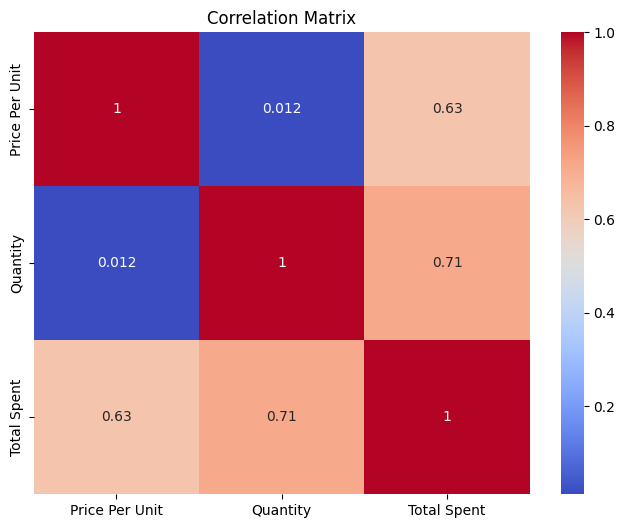

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [47]:
df["Discount Applied"].value_counts(dropna=False)

,count
Discount Applied,
True,4219
NaN,4199
False,4157


In [48]:
df.groupby("Discount Applied")["Total Spent"].agg(
    ["count", "mean", "sum"])

,count,mean,sum
Discount Applied,,,
False,3964,129.953330,515135.0
True,4019,130.491043,524443.5


In [49]:
category_location = pd.pivot_table(
    df,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum"
)

category_location

Location,In-store,Online
Category,,
Beverages,98026.0,99021.5
Butchers,101777.0,106341.0
Computers and electric accessories,87323.5,103369.0
Electric household essentials,97778.5,106035.0
Food,95926.0,98886.0
Furniture,99611.0,95699.0
Milk Products,88813.0,91299.0
Patisserie,91415.0,90750.5


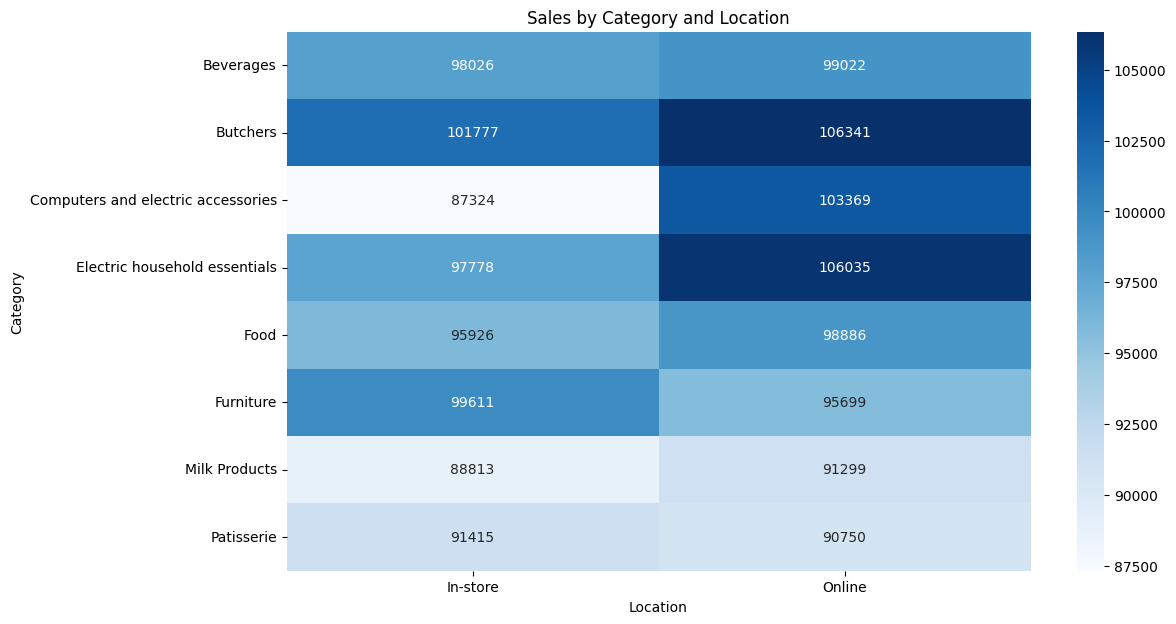

In [50]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    category_location,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Sales by Category and Location")
plt.show()

In [51]:
weekday_sales = df.groupby("Day of Week")["Total Spent"].sum()

weekday_sales

,Total Spent
Day of Week,
Friday,232786.0
Monday,213090.5
Saturday,224191.0
Sunday,225991.0
Thursday,219380.5
Tuesday,219650.0
Wednesday,216982.0


In [52]:
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = df.groupby("Day of Week")["Total Spent"].sum()
weekday_sales = weekday_sales.reindex(days)

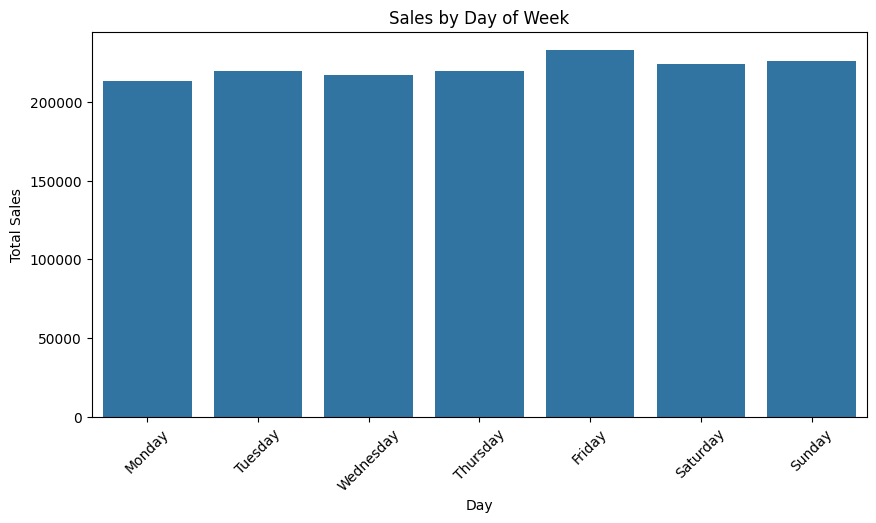

In [53]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [54]:
top_items = (
    df.groupby("Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10))

top_items

,Quantity
Item,
Item_2_BEV,676.0
Item_16_MILK,627.0
Item_25_FUR,616.0
Item_19_MILK,589.0
Item_5_FUR,581.0
Item_13_FOOD,581.0
Item_1_MILK,578.0
Item_11_MILK,574.0
Item_11_FUR,573.0


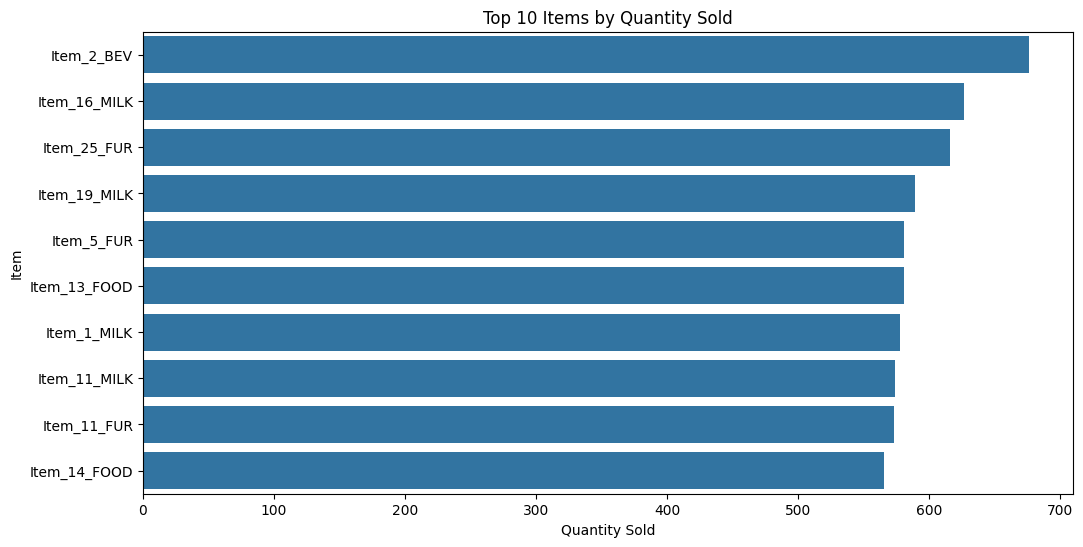

In [55]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_items.values,
    y=top_items.index)

plt.title("Top 10 Items by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Item")
plt.show()

In [56]:
top_revenue_items = (
    df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .head(10))

top_revenue_items

,Total Spent
Item,
Item_25_FUR,25256.0
Item_25_EHE,23083.0
Item_25_BUT,21894.0
Item_24_FUR,21172.0
Item_25_FOOD,20541.0
Item_22_BUT,19710.0
Item_23_BUT,19114.0
Item_20_BUT,18860.5
Item_19_MILK,18848.0


In [57]:
df.to_csv("cleaned_retail_store_sales.csv", index=False)

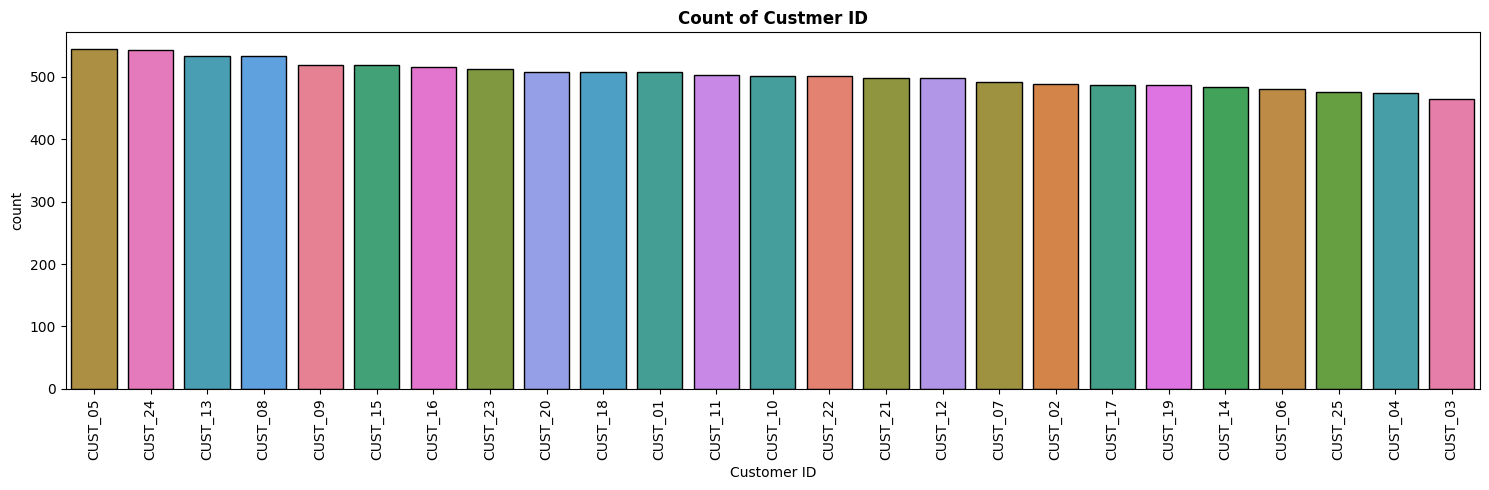

In [58]:
plt.figure(figsize = (15, 5))
sns.countplot(data = df, x = 'Customer ID', hue = 'Customer ID', order = df['Customer ID'].value_counts().index, edgecolor = 'black')
plt.title('Count of Custmer ID', fontweight = 'bold')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

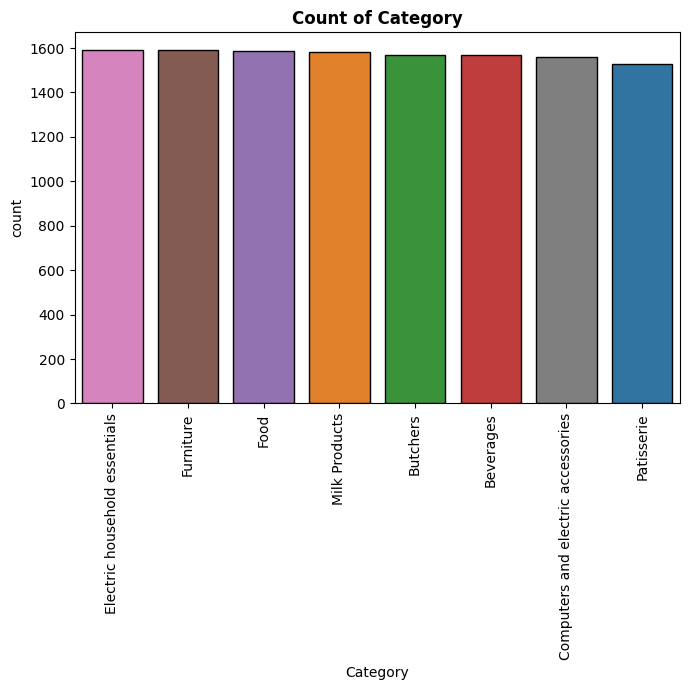

In [59]:
plt.figure(figsize = (7, 7))
sns.countplot(data = df, x = 'Category', hue = 'Category', order = df['Category'].value_counts().index, edgecolor = 'black')
plt.title('Count of Category', fontweight = 'bold')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

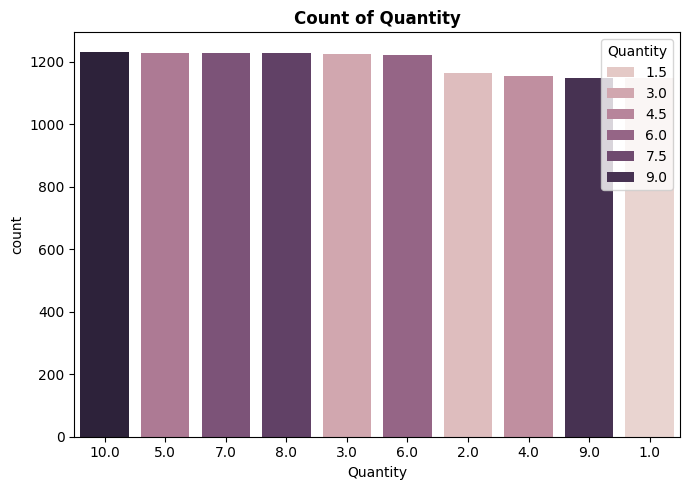

In [60]:
plt.figure(figsize = (7, 5))
sns.countplot(data = df, x = 'Quantity', hue = 'Quantity', order = df['Quantity'].value_counts().index)
plt.title('Count of Quantity', fontweight = 'bold')
plt.tight_layout()
plt.show()

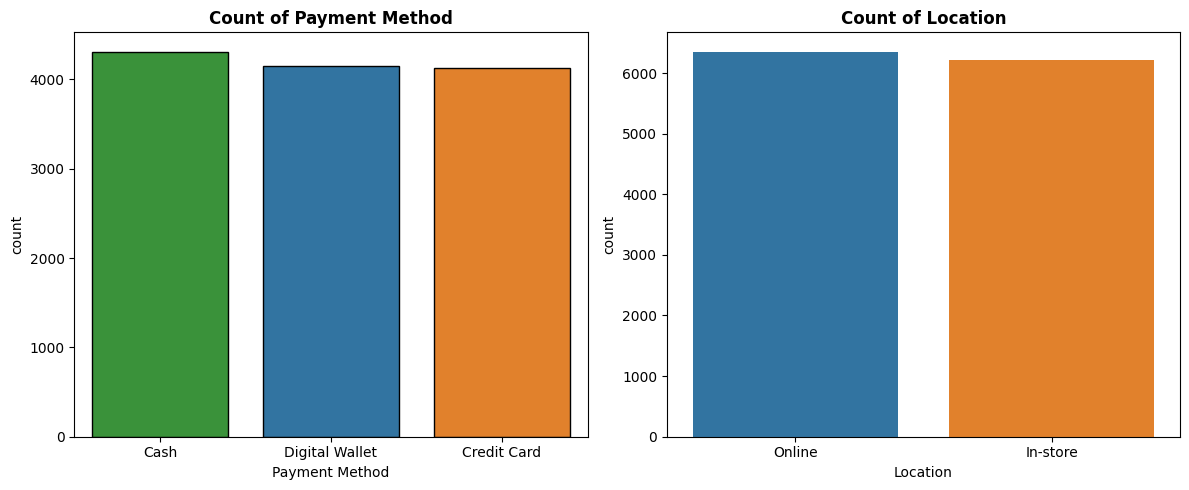

In [61]:
fig, axis = plt.subplots(1, 2, figsize = (12, 5))
sns.countplot(data = df, x = 'Payment Method', hue = 'Payment Method', order = df['Payment Method'].value_counts().index, edgecolor = 'black', ax = axis[0])
axis[0].set_title('Count of Payment Method', fontweight = 'bold')

sns.countplot(data = df, x = 'Location', hue = 'Location', order = df['Location'].value_counts().index, ax = axis[1])
axis[1].set_title('Count of Location', fontweight = 'bold')

plt.tight_layout()
plt.show()

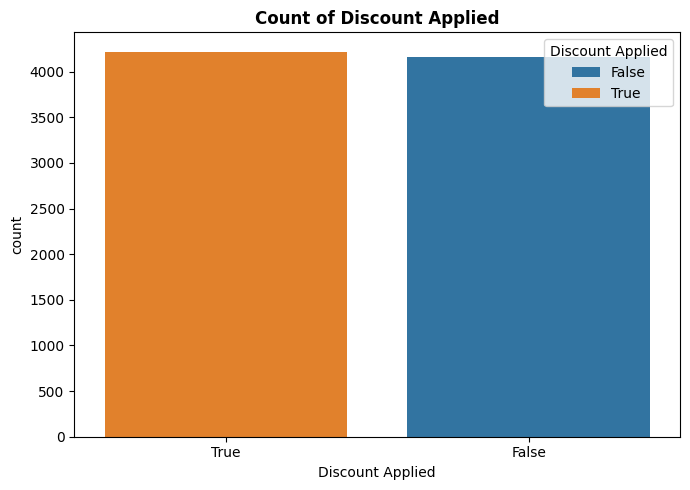

In [62]:
plt.figure(figsize = (7, 5))
sns.countplot(data = df, x = 'Discount Applied', hue = 'Discount Applied', order = df['Discount Applied'].value_counts().index)
plt.title('Count of Discount Applied', fontweight = 'bold')
plt.tight_layout()
plt.show()

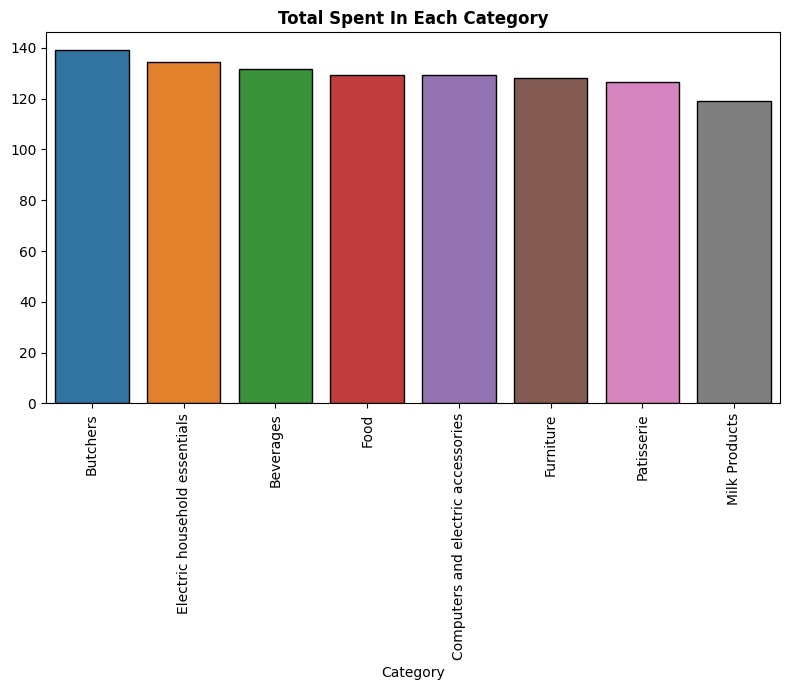

In [63]:
group1 = df.groupby('Category')['Total Spent'].mean().sort_values(ascending = False)

plt.figure(figsize = (8, 7))
sns.barplot(x = group1.index, y = group1.values, hue = group1.index, edgecolor = 'black')
plt.title('Total Spent In Each Category', fontweight = 'bold')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

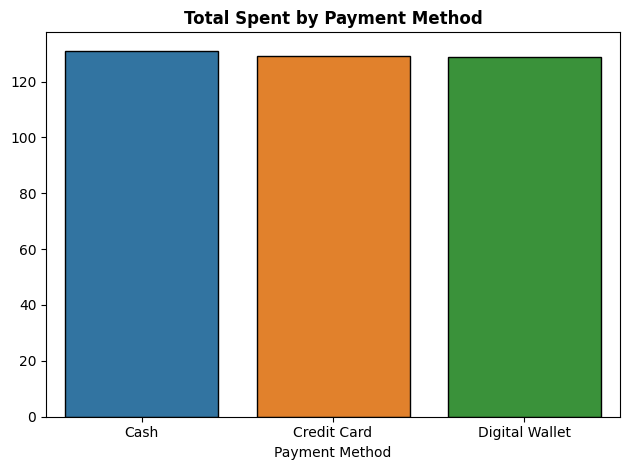

In [64]:
group2 = df.groupby('Payment Method')['Total Spent'].mean().sort_values(ascending = False)

sns.barplot(x = group2.index, y = group2.values, hue = group2.index, edgecolor = 'black')
plt.title('Total Spent by Payment Method', fontweight = 'bold')
plt.tight_layout()
plt.show(

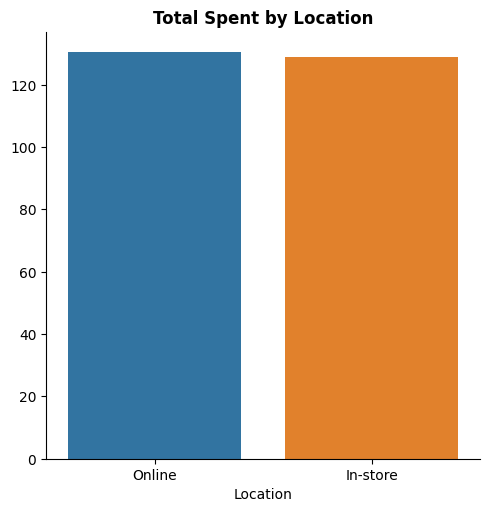

In [65]:
group3 = df.groupby('Location')['Total Spent'].mean().sort_values(ascending = False)

sns.catplot(x = group3.index, y = group3.values, hue = group3.index, kind = 'bar')
plt.title('Total Spent by Location', fontweight = 'bold')
plt.show()



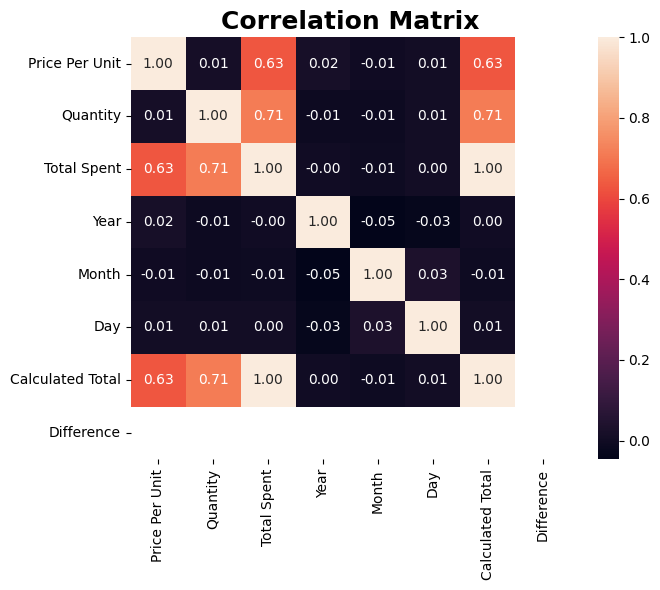

In [66]:
plt.figure(figsize = (7, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True, fmt = '.2f')
plt.title('Correlation Matrix', fontweight = 'bold', fontsize = 18)
plt.tight_layout()
plt.show()